# 02 — Veri Temizleme

Çelişkili ve tekrarlı metinler kaldırılır, yorumlar normalize edilir ve eğitim/test dosyaları oluşturulur.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

proje_koku = Path.cwd()
if proje_koku.name == "notebooks":
    proje_koku = proje_koku.parent

raw_data_path = proje_koku / "data" / "raw" / "hepsiburada_balanced_300k.csv"
df = pd.read_csv(raw_data_path)
df.head()


,combined_text,label
0,İki Yıldız. iyi,0
1,Bir Yıldız. kargo sorunsuz geldi ama tam 1 haf...,0
2,Kokusu dışında iş görür. Çok fazla koku yapıyo...,0
3,kötü. saat içinden çıkıyor beklediğim gibi kal...,0
4,Çok kötü.... Almayın çok kötü boşa para verirs...,0


In [3]:
# Aynı metnin kaç farklı etiketi olduğunu bul
etiket_sayilari = (
    df.groupby("combined_text")["label"]
      .nunique()
)

# Birden fazla etikete sahip metinler
celiskili_metinler = etiket_sayilari[
    etiket_sayilari > 1
].index

print("Çelişkili metin sayısı:", len(celiskili_metinler))

# Çelişkili metinlerin bütün satırlarını çıkar
df_temiz = df[
    ~df["combined_text"].isin(celiskili_metinler)
].copy()

# Geri kalan aynı metinlerden yalnızca ilkini bırak
df_temiz = df_temiz.drop_duplicates(
    subset=["combined_text"],
    keep="first"
)

# İndeksi sıfırla
df_temiz = df_temiz.reset_index(drop=True)

Çelişkili metin sayısı: 33


In [4]:
print("Eski boyut:", df.shape)
print("Yeni boyut:", df_temiz.shape)

print("\nSınıf dağılımı:")
print(df_temiz["label"].value_counts().sort_index())

print("\nKalan duplicate:")
print(df_temiz["combined_text"].duplicated().sum())

print("\nKalan çelişkili metin:")
print(
    (df_temiz.groupby("combined_text")["label"].nunique() > 1).sum()
)

Eski boyut: (300000, 2)
Yeni boyut: (246949, 2)

Sınıf dağılımı:
label
0    77186
1    79219
2    90544
Name: count, dtype: int64

Kalan duplicate:
0

Kalan çelişkili metin:
0


In [5]:
# Her sınıftan rastgele 10 örnek incele
for etiket in sorted(df_temiz["label"].unique()):
    print("\n" + "=" * 50)
    print("LABEL:", etiket)
    print("=" * 50)

    ornekler = df_temiz[df_temiz["label"] == etiket].sample(
        10,
        random_state=42
    )

    for metin in ornekler["combined_text"]:
        print("-", metin)


LABEL: 0
- paketleniş süper. ışığı tahmin ettiğimden daha güçlü çıkmasına karşın daha ilk kullanışta aç kapa tuşu kırıldı
- resimde gözüktüğü gibi kalın değil . Ürün resimdeki gibi şeffaf kısmı kalın değil işimi görmeyecek nikelaj yapıştırmak için almıştım başka işlerde kullanılabilir hızlı kargo için teşekkürler
- İki Yıldız. Beklenen tost keyfini yaşamak için çok zayıf bir makina Rezistansı çok çabuk devreden çıkıyor ve tost yapmak için uzun süre beklemeniz gerekiyor Fiyatının çok altında bir kalitede
- Daha iyisi var. Kulaklığın bass sesleri zayıf ve dış sesleri fazla geçiriyor pek memnun kalmadım Bu fiyatlara kardeşime Anker marka kablosuz kulaklık almıştım ses kalitesi çok daha tatmin ediciydi ve su geçirmezdi bunun yerine onu tavsiye ederim
- cok kotu. hemen yan odadan bile cekmiyor kamera ile el unitesi arasinda 10 mt yok ama surekli sebeke sinyali veriyor ve gece gorusu hicbir ise yaramaz
- memnuniyetsiz.. 07 06 2018 perşembe gün Abre Vm 348345 Ceviz Vestiyer Portmanto Ayakkab

label
Olumsuz     77186
Tarafsız    79219
Olumlu      90544
Name: count, dtype: int64


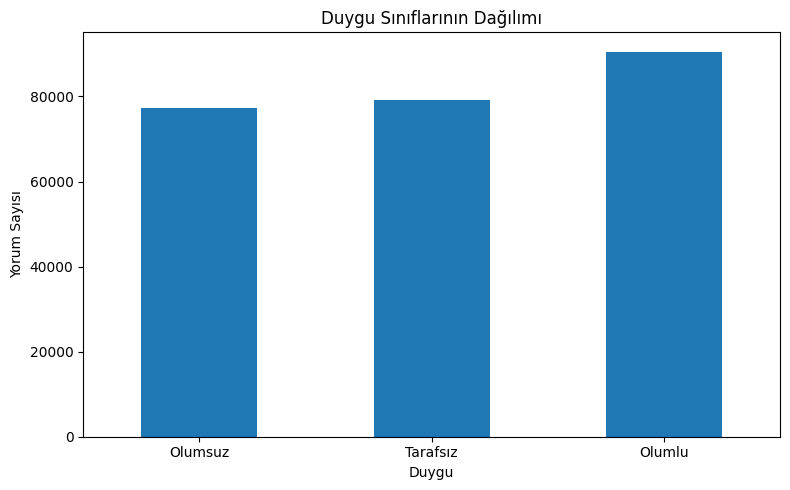

In [6]:
etiket_isimleri = {
    0: "Olumsuz",
    1: "Tarafsız",
    2: "Olumlu"
}
# Etiket sayılarını hesapla
etiket_sayilari = (
    df_temiz["label"]
    .value_counts()
    .sort_index()
)

# Sayısal etiketleri duygu isimlerine çevir
etiket_sayilari.index = etiket_sayilari.index.map(etiket_isimleri)

print(etiket_sayilari)

# Grafik
plt.figure(figsize=(8, 5))
etiket_sayilari.plot(kind="bar")

plt.title("Duygu Sınıflarının Dağılımı")
plt.xlabel("Duygu")
plt.ylabel("Yorum Sayısı")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
df_temiz["temiz_metin"] = (
    df_temiz["combined_text"]
    .astype(str)

    # HTML etiketlerini kaldır
    .str.replace(r"<[^>]+>", " ", regex=True)

    # URL'leri kaldır
    .str.replace(r"https?://\S+|www\.\S+", " ", regex=True)

    # Nokta ve virgülleri kaldır
    .str.replace(r"[.,]", " ", regex=True)

    # Birden fazla boşluğu tek boşluğa indir
    .str.replace(r"\s+", " ", regex=True)

    # Baştaki ve sondaki boşlukları kaldır
    .str.strip()
)

In [8]:
print("Boş metin sayısı:", (df_temiz["temiz_metin"] == "").sum())
print(
    "Temizlik sonrası duplicate:",
    df_temiz["temiz_metin"].duplicated().sum()
)

Boş metin sayısı: 0
Temizlik sonrası duplicate: 20


In [9]:
df_temiz = df_temiz[
    df_temiz["temiz_metin"] != ""
].copy()

df_temiz = df_temiz.drop_duplicates(
    subset=["temiz_metin"],
    keep="first"
).reset_index(drop=True)

In [10]:
df_temiz["karakter_sayisi"] = df_temiz["temiz_metin"].str.len()

df_temiz["kelime_sayisi"] = (
    df_temiz["temiz_metin"]
    .str.split()
    .str.len()
)

df_temiz[["karakter_sayisi", "kelime_sayisi"]].describe()

,karakter_sayisi,kelime_sayisi
count,246929.000000,246929.000000
mean,169.984822,25.074455
std,145.358612,21.016370
min,7.000000,1.000000
25%,78.000000,12.000000
50%,134.000000,20.000000
75%,213.000000,31.000000
max,2064.000000,328.000000


In [11]:
df_temiz[df_temiz["kelime_sayisi"] == 1][
    ["temiz_metin", "label"]
].head(30)

,temiz_metin,label
229174,KALİTELİ,2


In [12]:
df_temiz.head(25)

,combined_text,label,temiz_metin,karakter_sayisi,kelime_sayisi
0,İki Yıldız. iyi,0,İki Yıldız iyi,14,3
1,Bir Yıldız. kargo sorunsuz geldi ama tam 1 haf...,0,Bir Yıldız kargo sorunsuz geldi ama tam 1 haft...,134,21
2,Kokusu dışında iş görür. Çok fazla koku yapıyo...,0,Kokusu dışında iş görür Çok fazla koku yapıyor...,540,77
3,kötü. saat içinden çıkıyor beklediğim gibi kal...,0,kötü saat içinden çıkıyor beklediğim gibi kali...,90,13
4,Çok kötü.... Almayın çok kötü boşa para verirs...,0,Çok kötü Almayın çok kötü boşa para verirsiniz...,113,18
5,Bir Yıldız. Cok kalitesiz bir urun kara tahta ...,0,Bir Yıldız Cok kalitesiz bir urun kara tahta k...,183,24
6,tuş basmıyor. bazı tuşlar basmıyor esc özellik...,0,tuş basmıyor bazı tuşlar basmıyor esc özellikl...,74,11
7,Demlik kısmındaki çay soğuyor. Sürekli ısıtma ...,0,Demlik kısmındaki çay soğuyor Sürekli ısıtma y...,174,24
8,Damak tadı uymadi. Yorumlara bakarak 3 paket s...,0,Damak tadı uymadi Yorumlara bakarak 3 paket si...,333,50
9,eksik urun . aldığım urunun ayakları yok eksik...,0,eksik urun aldığım urunun ayakları yok eksik c...,137,20


In [13]:
df_temiz = df_temiz.drop(
    columns=["karakter_sayisi", "kelime_sayisi"]
)

In [14]:
df_temiz.head()

,combined_text,label,temiz_metin
0,İki Yıldız. iyi,0,İki Yıldız iyi
1,Bir Yıldız. kargo sorunsuz geldi ama tam 1 haf...,0,Bir Yıldız kargo sorunsuz geldi ama tam 1 haft...
2,Kokusu dışında iş görür. Çok fazla koku yapıyo...,0,Kokusu dışında iş görür Çok fazla koku yapıyor...
3,kötü. saat içinden çıkıyor beklediğim gibi kal...,0,kötü saat içinden çıkıyor beklediğim gibi kali...
4,Çok kötü.... Almayın çok kötü boşa para verirs...,0,Çok kötü Almayın çok kötü boşa para verirsiniz...


In [15]:
df_temiz = df_temiz[["temiz_metin", "label"]]

In [16]:
df_temiz.head()

,temiz_metin,label
0,İki Yıldız iyi,0
1,Bir Yıldız kargo sorunsuz geldi ama tam 1 haft...,0
2,Kokusu dışında iş görür Çok fazla koku yapıyor...,0
3,kötü saat içinden çıkıyor beklediğim gibi kali...,0
4,Çok kötü Almayın çok kötü boşa para verirsiniz...,0


In [17]:
df_temiz["temiz_metin"] = (
    df_temiz["temiz_metin"]
    .str.replace("I", "ı", regex=False)
    .str.replace("İ", "i", regex=False)
    .str.lower()
)

In [18]:
df_temiz["temiz_metin"] = (
    df_temiz["temiz_metin"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [19]:
print(
    "Küçük harfe dönüşüm sonrası duplicate:",
    df_temiz["temiz_metin"].duplicated().sum()
)

Küçük harfe dönüşüm sonrası duplicate: 867


In [20]:
df_temiz = (
    df_temiz
    .drop_duplicates(subset=["temiz_metin"], keep="first")
    .reset_index(drop=True)
)

In [21]:
df_temiz[["temiz_metin", "label"]].head(10)

,temiz_metin,label
0,iki yıldız iyi,0
1,bir yıldız kargo sorunsuz geldi ama tam 1 haft...,0
2,kokusu dışında iş görür çok fazla koku yapıyor...,0
3,kötü saat içinden çıkıyor beklediğim gibi kali...,0
4,çok kötü almayın çok kötü boşa para verirsiniz...,0
5,bir yıldız cok kalitesiz bir urun kara tahta k...,0
6,tuş basmıyor bazı tuşlar basmıyor esc özellikl...,0
7,demlik kısmındaki çay soğuyor sürekli ısıtma y...,0
8,damak tadı uymadi yorumlara bakarak 3 paket si...,0
9,eksik urun aldığım urunun ayakları yok eksik c...,0


In [22]:
print(df_temiz.shape)

print("\nNull değerler:")
print(df_temiz.isnull().sum())

print("\nDuplicate sayısı:")
print(df_temiz["temiz_metin"].duplicated().sum())

print("\nEtiket dağılımı:")
print(df_temiz["label"].value_counts().sort_index())

(246062, 2)

Null değerler:
temiz_metin    0
label          0
dtype: int64

Duplicate sayısı:
0

Etiket dağılımı:
label
0    77017
1    79028
2    90017
Name: count, dtype: int64


In [23]:
from sklearn.model_selection import train_test_split

X = df_temiz["temiz_metin"]
y = df_temiz["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train veri sayısı:", len(X_train))
print("Test veri sayısı:", len(X_test))

print("\nTrain dağılımı:")
print(y_train.value_counts().sort_index())

print("\nTest dağılımı:")
print(y_test.value_counts().sort_index())

Train veri sayısı: 196849
Test veri sayısı: 49213

Train dağılımı:
label
0    61614
1    63222
2    72013
Name: count, dtype: int64

Test dağılımı:
label
0    15403
1    15806
2    18004
Name: count, dtype: int64


In [24]:
train_df = pd.DataFrame({
    "temiz_metin": X_train,
    "label": y_train,
}).reset_index(drop=True)

test_df = pd.DataFrame({
    "temiz_metin": X_test,
    "label": y_test,
}).reset_index(drop=True)

processed_dir = proje_koku / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(processed_dir / "hbtrain.csv", index=False, encoding="utf-8-sig")
test_df.to_csv(processed_dir / "hbtest.csv", index=False, encoding="utf-8-sig")

print("Kaydedildi:", processed_dir / "hbtrain.csv")
print("Kaydedildi:", processed_dir / "hbtest.csv")


Kaydedildi: c:\Users\Muhammet Ali Balci\OneDrive\Masaüstü\duyguanalizistaj\data\processed\hbtrain.csv
Kaydedildi: c:\Users\Muhammet Ali Balci\OneDrive\Masaüstü\duyguanalizistaj\data\processed\hbtest.csv
